In [1]:
from pathlib import Path
import json
import numpy as np


In [2]:
def camera_param_init():
    camera_param = {
        "intrisics":None,
        "extrisics":None,
        "width":None,
        "height":None,
        "distortion":None 
    }
    return camera_param

def ros_camera_info_to_camera_param(camera_info):
    camera_param = camera_param_init()
    camera_param["intrisics"] = camera_info["K"]
    camera_param["width"] = camera_info["width"]
    camera_param["height"] = camera_info["height"]
    camera_param["distortion"] = camera_info["D"]
    return camera_param

def load_camera_intrics(folder_path,cam_index = 0):
    camera_param = camera_param_init()
    camera_info_path = Path(folder_path) / Path(f"cam{cam_index}/rgb/camera_info/info.txt")
    with open(camera_info_path,"r") as json_file:
        camera_info = json.load(json_file)
    camera_param = ros_camera_info_to_camera_param(camera_info)
    return camera_param

def load_camera_extrisics(folder_path):
    global_name_postion_path = Path(folder_path) / Path("global_name_position/0.txt")
    global_name_postion = None
    with open(global_name_postion_path,"r") as json_file:
        global_name_postion = json.load(json_file)
    return global_name_postion["cam0_rgb_camera_link"]


def load_camera_param(folder_path,cam_index = 0):
    #load_intrisics
    camera_param = load_camera_intrics(folder_path,cam_index)
    camera_param["extrisics"] = np.linalg.inv(load_camera_extrisics(folder_path))
    return camera_param


In [3]:
import pyrender
import trimesh
import matplotlib.pyplot as plt

def transform_arm_hand_to_2d_cam(folder_path,cam_index = 0):
    
    camera_param = load_camera_param(folder_path,cam_index)

    # 从您提供的摄像机参数中提取内外参数

    intrinsics = pyrender.IntrinsicsCamera(
        fx=camera_param["intrisics"][0],
        fy=camera_param["intrisics"][4],
        cx=camera_param["intrisics"][2],
        cy=camera_param["intrisics"][5],
        znear=0.1,
        zfar=1000.0
    )

    # 加载3D模型
    model_path = Path(folder_path) / Path("arm_hand_mesh/0.ply")
    mesh = trimesh.load(str(model_path))  # 请替换为您的模型路径
    scene = pyrender.Scene()

    # 添加3D模型到场景
    pyrender_mesh = pyrender.Mesh.from_trimesh(mesh)
    scene.add(pyrender_mesh)

    # 添加光源
    light = pyrender.PointLight(color=np.ones(3), intensity=5.0)
    light_pose = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 1, 8],  # 5 units above the model
        [0, 0, 0, 1]
    ])
    scene.add(light, pose=light_pose)

    # 使用您提供的参数设置摄像机
    scene.add(intrinsics, pose=camera_param["extrisics"])

    # 渲染场景到2D图像
    renderer = pyrender.OffscreenRenderer(camera_param["width"], camera_param["height"])  # 使用提供的摄像机宽度和高度
    color, _ = renderer.render(scene)

    plt.imshow(color)
    plt.show()

    # 如果需要，可以保存图像
    # plt.imsave("output_image.png", color)


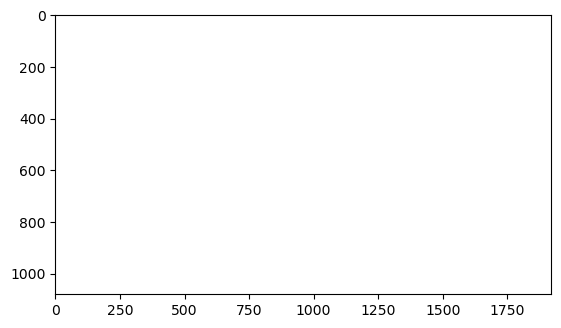

In [4]:
transform_arm_hand_to_2d_cam("/media/tony/T7/camera_data/banana")